#Table of contents
>[TensorFlow Time Series Forecasting Guide](#scrollTo=c3d22312)

>[Read In Pollution Dataset](#scrollTo=19cfaea6)

>[Impute Missing Dates](#scrollTo=eee312bd)

>[Split Dataset Into Train/Test](#scrollTo=1a3f9067)

>[Process Dataset with Windows](#scrollTo=d2da4469)

>[Custom Callback](#scrollTo=cdc68df2)

>[Predefined Callback - LearningRateScheduler](#scrollTo=8c93dd97)

>[Convolution Model](#scrollTo=f903798d)

>[Mixed Architecture Model](#scrollTo=93e57216)

>[Evaluate Models on Test Set](#scrollTo=f63fa932)



# TensorFlow Time Series Forecasting Guide

**In this notebook, I will demonstrate how to predict future values of univariate time series data
with models in Tensorflow.**

---------------------------------------------------------------------------------------------------


**This notebook will cover the following topics:**
- Visualizing time series data in matplotlib
- Using windows to preprocess time series data
- Creating custom callbacks
- Building LSTM based time series forecasting models
- Building Convolution-layer based time seires forecasting models
- Building mixed architecture models
- Evaluting time series forecast predictions

# Read In Pollution Dataset

The dataset we will be using comes from air quality sensors across South Korea. The sensors measure and record all types of air pollutants/particles in the air, but for this tutorial we will only look at PM<sub>2.5</sub> (fine dust).

Importing libraries

In [1]:
#Import Libraries
import tensorflow as tf
import numpy as np #Linear Algebra
import matplotlib.pyplot as plt #Data visualization
import pandas as pd #data manipulation

import warnings
warnings.filterwarnings('ignore') #Ignore warnings

#Make sure Tensorflow is version 2.0 or higher
print('Tensorflow Version:', tf.__version__)

Tensorflow Version: 2.12.0


The code reads pollution data from a CSV file, filters for PM2.5 values in the "Jeongnim-Dong" city, sorts the data by date, and selects a specific time range from 2018 to 2022. It then prints a sample of the time series data for the PM2.5 pollution values in the specified city.






In [2]:
#Reads in Pollution csv
pollution = pd.read_csv("data.csv",
                       parse_dates=['date'],
                       index_col='date')
#Filters for only pm25 values in Jeongnim-Dong City, sorted by date
pollution = pollution[pollution.City == 'Jeongnim-Dong'].pm25.sort_index()
#starts the dataset at 2018 and ends in 2022(due to breaks in data in previous years)
start = pd.to_datetime('2018-01-01')
end = pd.to_datetime('2022-01-01')
pollution = pollution[start:end]
print('SAMPLE OF TIME SERIES DATA:')
pollution.head()

SAMPLE OF TIME SERIES DATA:


date
2018-01-01    72
2018-01-02    95
2018-01-03    57
2018-01-04    70
2018-01-05    88
Name: pm25, dtype: int64

# Impute Missing Dates

The code checks for and imputes missing dates in the pollution time series data by creating a continuous date range from "2018-01-01" to "2022-01-01," comparing it with the existing time series dates, and filling in the missing dates with the previous value. It then sorts the data by date and sets the time index frequency as daily.






In [3]:
#Checks for and imputes missing dates
a = pd.date_range(start="2018-01-01", end="2022-01-01", freq="D") #continous dates
b = pollution.index #our time series
diff_dates = a.difference(b) # finds what in 'a' is not in 'b'

td = pd.Timedelta(1, "d") #1 day
for date in diff_dates:
    prev_val = pollution[date-td] #takes the previous value
    pollution[date] = prev_val #imputes previous value

pollution.sort_index(inplace=True)
#sets the time index frequency as daily
pollution.freq = "D"


The code creates a plot displaying the PM 2.5 values in Jeongnim-Dong City from 2018 to 2022. The x-axis represents the dates, the y-axis represents the PM 2.5 values, and the blue line connects the data points to show the trend over time.






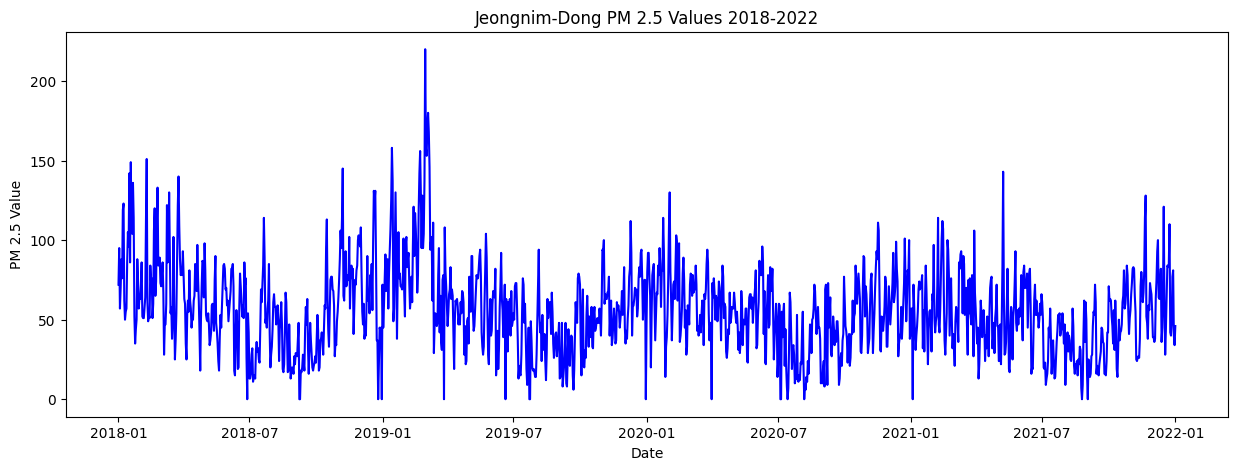

In [4]:
#displays a plot of the pm25 values since 2018
fig = plt.figure(figsize=(15,5))
plt.plot(pollution, color='blue')
plt.xlabel('Date')
plt.ylabel('PM 2.5 Value')
plt.title('Jeongnim-Dong PM 2.5 Values 2018-2022')
plt.show()

# Split Dataset Into Train/Test

The code splits the time series data into a train set containing data from January 2018 to December 2020 and a test set containing data from January 2021 to January 2022.






In [5]:
#Split the time series data into a train and test set
end_train_ix = pd.to_datetime('2020-12-31')
train = pollution[:end_train_ix] # Jan 2018-2021
test = pollution[end_train_ix:] # Jan 2021-2022

The code visualizes the train-test split of the time series data, showing the training data in purple and the testing data in orange.






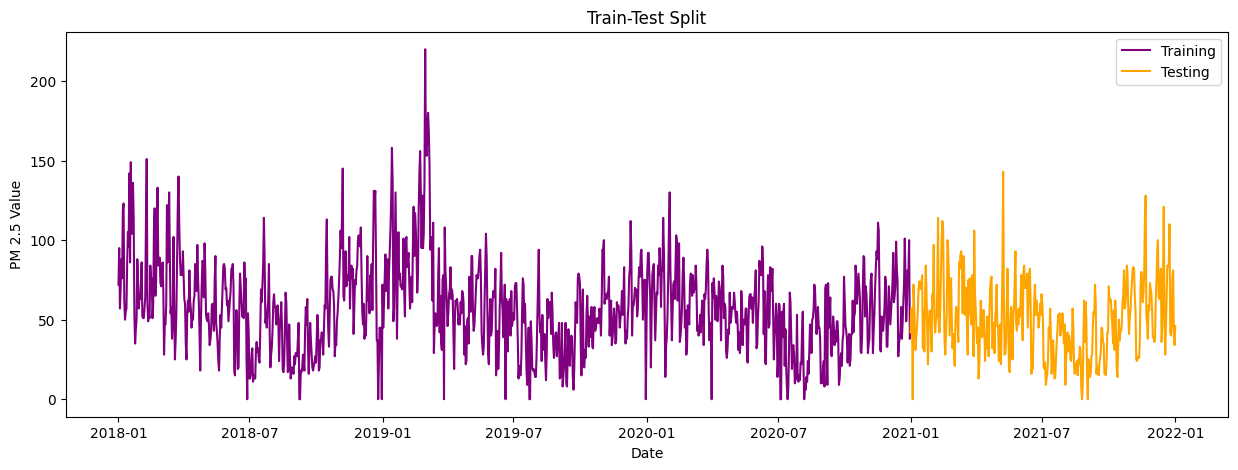

In [6]:
#displays a plot of the train/test split
fig = plt.figure(figsize=(15,5))
plt.plot(train, color='purple', label='Training')
plt.plot(test, color='orange', label='Testing')
plt.xlabel('Date')
plt.ylabel('PM 2.5 Value')
plt.title('Train-Test Split')
plt.legend()
plt.show()

# Process Dataset with Windows

Time series data needs to be sliced into windows before being sent to a ML model. A window is essentially a limited range snapshot of our time series data. Say we have an array of values:

`[1, 2, 3, 4, 5, 6, 7, 8, 9]`

If we have a window size of 4 and we want to forecast 1 timestep in advance, this would be the result:

```
[1, 2, 3, 4] [5]
[2, 3, 4, 5] [6]
[3, 4, 5, 6] [7]
[4, 5, 6, 7] [8]
[5, 6, 7, 8] [9]
```

The code creates a windowed dataset from the time series data with a window size of 14 days. It converts the data into a TensorSliceDataset, then takes slices of the dataset with a size of the window plus one. It flattens and batches the windowed data, creating tuples of features and targets, shuffles the dataset, and finally creates batches of windows for training.






In [7]:
#Creates a windowed dataset from the time series data
WINDOW = 14 #the window value... 14 days

#converts values to TensorSliceDataset
train_data = tf.data.Dataset.from_tensor_slices(train.values)

#takes window size + 1 slices of the dataset
train_data = train_data.window(WINDOW+1, shift=1, drop_remainder=True)

#flattens windowed data by batching
train_data = train_data.flat_map(lambda x: x.batch(WINDOW+1))

#creates features and target tuple
train_data = train_data.map(lambda x: (x[:-1], x[-1]))

#shuffles dataset
train_data = train_data.shuffle(1_000)

#creates batches of windows
train_data = train_data.batch(32).prefetch(1)

The `train_data` will now have batches of windowed time series data. The batches are filled with arrays of 14 pm25 values and their target values.

# Custom Callback

Callbacks are used in Tensorflow to allow user intervention during model training. A callback can be executed at a number of specific intances during model training.
For example:
- `on_batch_begin`/`end`
- `on_epoch_begin`/`end`
- `on_predict_batch_begin`/`end`
- `on_predict_begin`/`end`
- `on_test_batch_begin`/`end`
- `on_test_begin`/`end`
- `on_train_batch_begin`/`end`
- `on_train_begin`/`end`

We will create `CustomCallback` which will stop the model from training once the model reaches under 10 mean absolute error on the training set.

Link: https://keras.io/api/callbacks/

---
## Step 1 & 2: Time Series Pipeline (PyCaret)

Automated time series pipeline with PyCaret:
- `setup()` → preprocessing & configuration
- `compare_models()` → model selection
- `finalize_model()` → train on full data


In [ ]:
from pycaret.time_series import *

ts_setup = setup(data=df, target='None', fh=12, session_id=42, verbose=False)

# Compare models and select best
best_model = compare_models()

# Display comparison results
print(best_model)


In [ ]:
# Plot forecast
plot_model(best_model, plot='forecast')


In [ ]:
# Finalize the model
final_model = finalize_model(best_model)

# Make predictions
predictions = predict_model(final_model)
print(predictions)